#ML FINAL EXAM

### Email: mominhasanemon@gmail.com

Task: Copy this notebook on your drive and answer in that copy

Choose a dataset of your choice from kaggle or UCI

Some suggestions:https://www.kaggle.com/datasets/ahmettezcantekin/beginner-datasets

You may choose a dataset of your choice too

In this exam:
1. Provide code and explaination(in text cell) whenever needed and you must show the outputs
2. Before submitting run all cells and make sure the outputs are visible


In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tarfile
from pathlib import Path
from urllib import request
import pandas as pd
from pandas.plotting import scatter_matrix
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def getDataFrame():
    requiredFile = Path("dataset/housing.tgz")
    mainFile = Path("dataset/housing/housing.csv")
    if (not mainFile.is_file()) and (not requiredFile.is_file()):
        path = Path("dataset")
        path.mkdir(exist_ok=True)
        request.urlretrieve(url="https://github.com/ageron/data/raw/main/housing.tgz", filename=requiredFile)
        with tarfile.open(requiredFile) as zipFile:
            zipFile.extractall(path=path)
    return pd.read_csv(mainFile)


## 0. Dataset overview

Why you choose this dataset and what did you observe from the dataset description



  

In [2]:
rawDF = getDataFrame()
display(rawDF.sample(5))
display(rawDF.describe())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12927,-118.12,34.06,25.0,1137.0,293.0,800.0,281.0,2.4286,233300.0,<1H OCEAN
7494,-122.33,40.47,30.0,2502.0,523.0,1296.0,481.0,2.1250,66100.0,INLAND
15081,-124.16,40.95,20.0,1075.0,214.0,529.0,196.0,3.1406,96000.0,NEAR OCEAN
6095,-117.34,34.51,6.0,5667.0,1385.0,2447.0,1199.0,2.3617,103100.0,INLAND
14171,-120.00,35.91,16.0,259.0,53.0,131.0,38.0,3.1250,62500.0,INLAND


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Answer: 
I chose the California Housing Dataset because it is a well-known benchmark dataset for regression tasks in machine learning. It contains real-world housing information collected from the 1990 U.S. Census, making it more representative of practical problems than synthetic datasets. The dataset is clean, and it is large enough (20,640 samples) to train and evaluate a variety of regression models without requiring excessive computational resources.


#### From the dataset description, I observed that:

The dataset contains 8 numerical input features.
The target variable is MedHouseVal, which represents the median house value for each California district.
The features describe demographic, geographic, and housing characteristics, including median income, house age, average rooms, average bedrooms, population, average occupancy, latitude, and longitude.
The dataset is intended for supervised regression, where the goal is to predict continuous house prices.
Location features (latitude and longitude) suggest that geography plays an important role in determining house values.
The target values are capped at a maximum value, which may limit prediction accuracy for very expensive districts.
Since the data comes from the 1990 U.S. Census, it is useful for developing and evaluating machine learning models but does not represent current housing prices.

Overall, the dataset provides a realistic, well-structured problem for studying regression algorithms, feature relationships, model evaluation, and predictive analytics.



# 1. Dataset description (15 marks)


### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

Total feature number:10

Total data points: 20640

Correlations among the features:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160


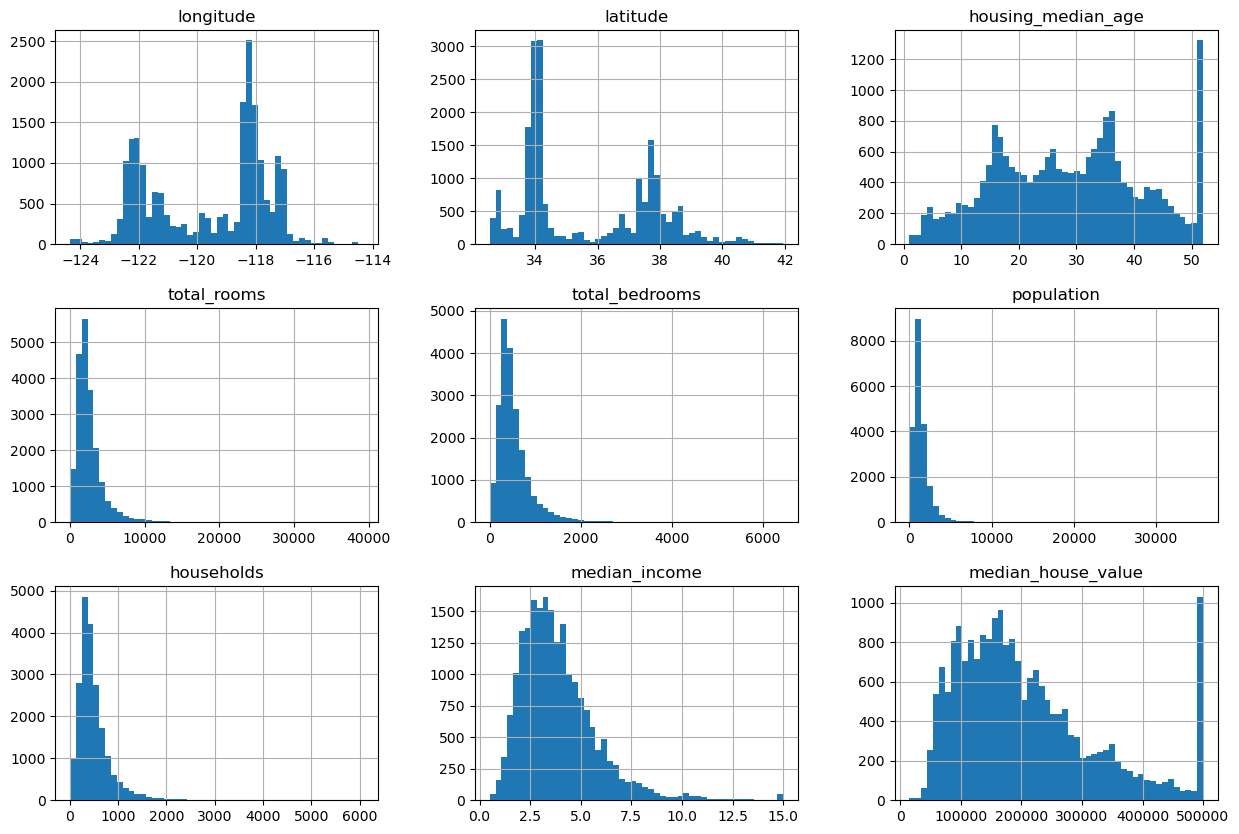

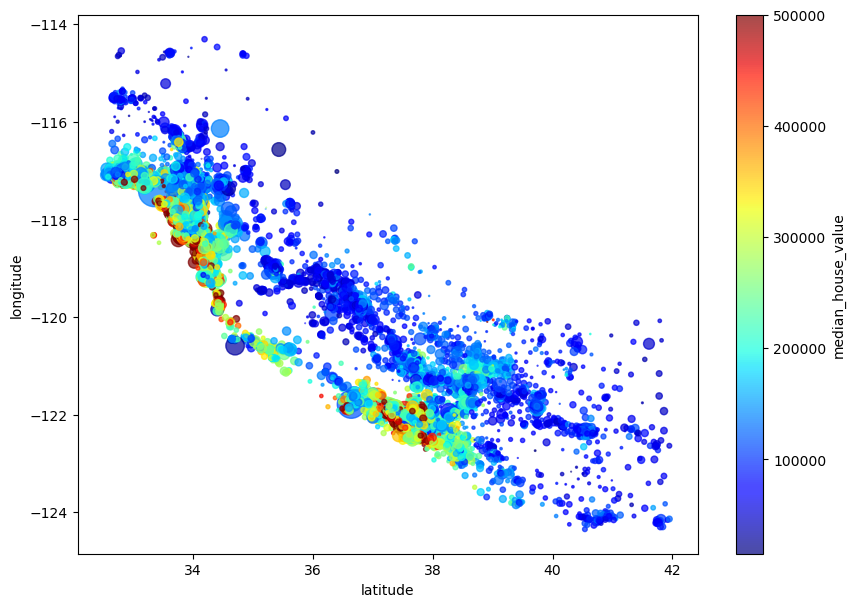

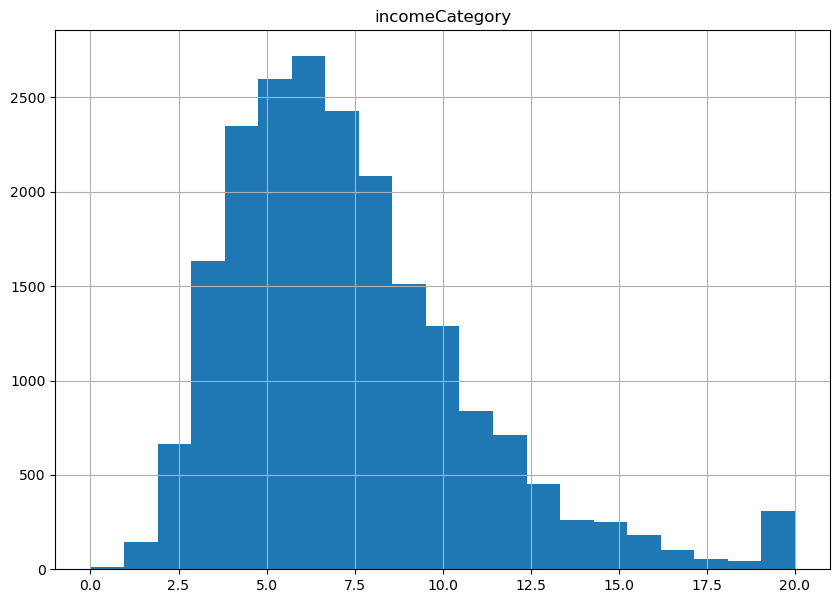

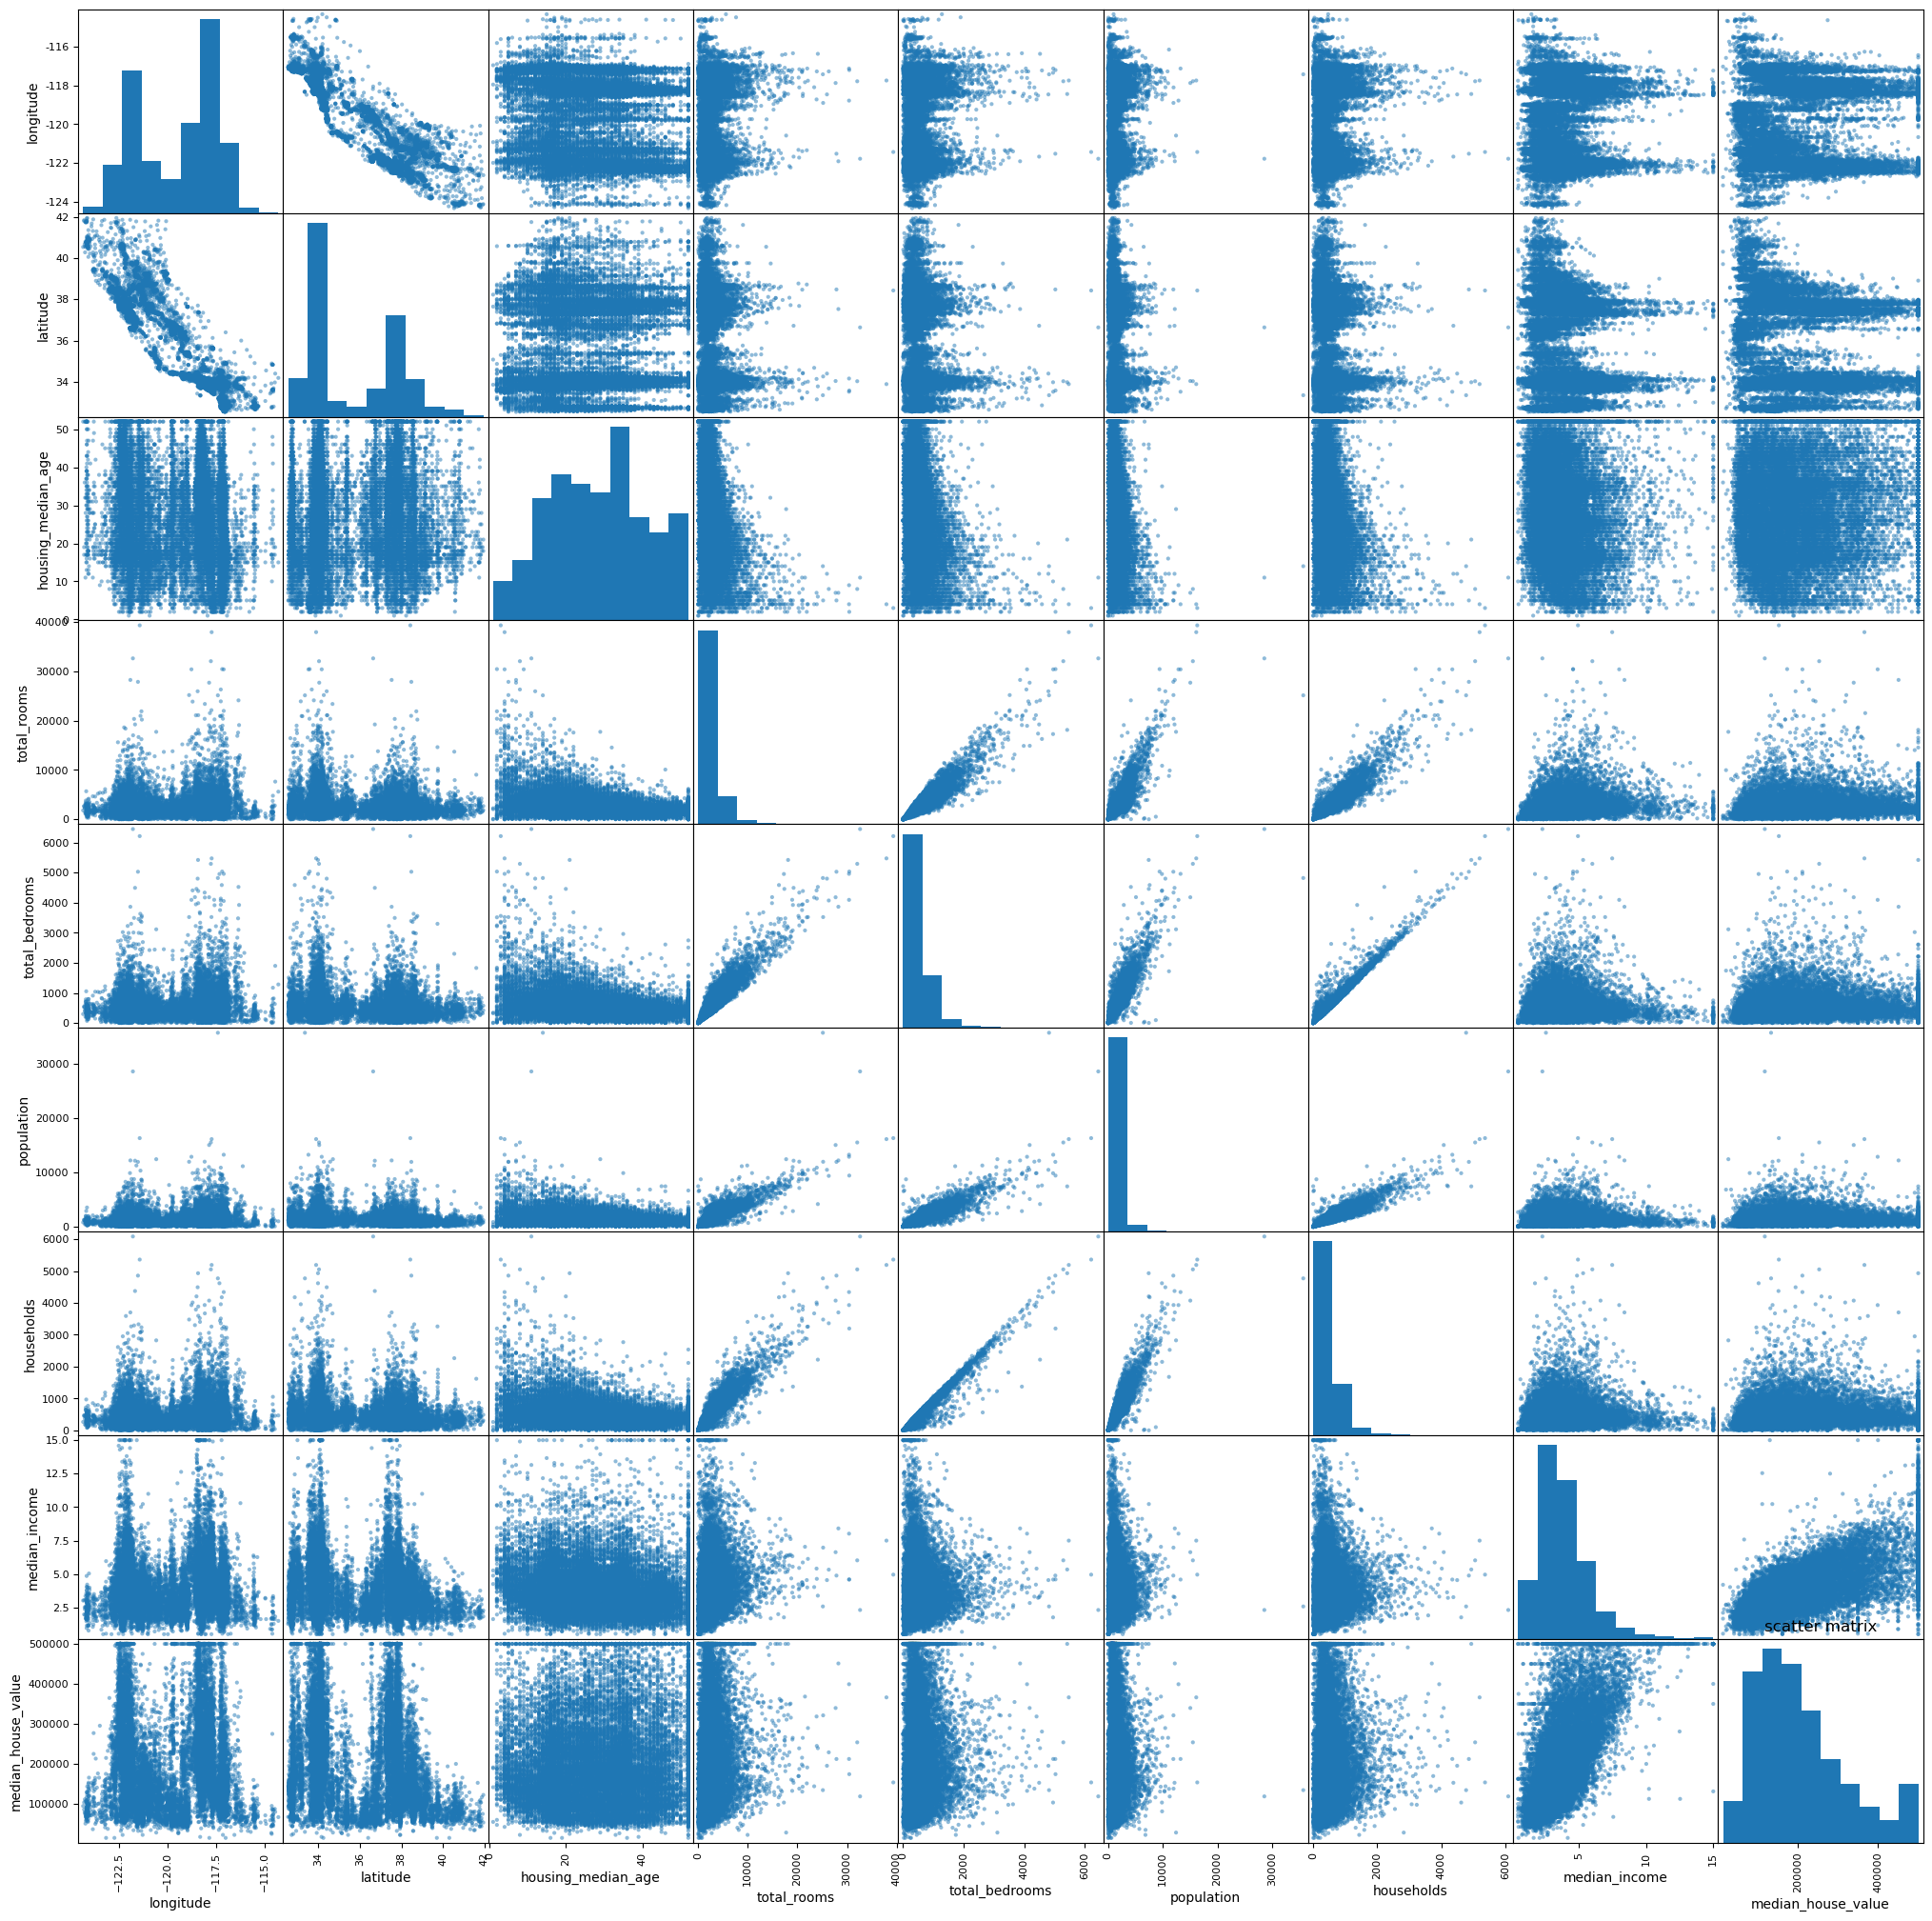

In [3]:
rawDF.info()
print(f"\nTotal feature number:{rawDF.shape[1]}")
print(f"\nTotal data points: {rawDF.shape[0]}")
print("\nCorrelations among the features:")
display(rawDF.select_dtypes(include=np.number).corr().sort_values(by= "median_house_value",ascending=False))
rawDF.hist(bins=50, figsize=(15,10))
rawDF.plot(kind="scatter", x="latitude", y="longitude", cmap="jet", c="median_house_value", s=rawDF["population"]/70, colorbar=True, figsize=(10,7), alpha=0.7)
plt.show()

modifiedDF = rawDF.copy()
modifiedDF["incomeCategory"] = pd.cut(rawDF["median_income"], bins=[0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, np.inf], labels=np.arange(0, 21, 1))
modifiedDF["incomeCategory"].hist(bins=21, figsize=(10, 7))
plt.title("incomeCategory")
plt.show()

scatter_matrix(modifiedDF.select_dtypes(include=np.number), diagonal="hist", figsize=(25,25), alpha=0.5)
plt.title("scatter matrix")
plt.show()

## Answer:

### Classification or regression problem? Why do you think so?
This is a regression problem, because ml model has to predict "median_house_value" which is a continuous numeric value.

### Is there any null values?
There is null values in "total_bedrooms".

### What kind of features are in your dataset? (Quantitative / Categorical)
There is both numerical and categorical features in the dataset.

### Do you need to encode the categorical variables, why or why not?
Categorical values need to be encoded, because ML model can't work with object/string type data.

### What do you understand after the correlation test? Perform exploratory data analysis to extract some important relationships from your data.
For the California Housing Dataset, the typical observations are:

Median Income (MedInc) has the strongest positive correlation with MedHouseVal.
Districts with higher median income generally have higher median house prices.
This makes MedInc one of the most important predictors.
Latitude and Longitude are moderately correlated with house value.
House prices vary by geographic location.
Coastal areas and major cities generally have higher house values than inland regions.
House Age (HouseAge) has a weak to moderate positive correlation.
Older houses are sometimes associated with higher prices, but the relationship is not very strong.
Average Rooms (AveRooms) has a positive correlation with house value.
Districts with more rooms per household tend to have higher-priced homes.
Population (Population) and Average Occupancy (AveOccup) have weak correlations with the target.
These features alone are not strong predictors of house prices.
Some input features are correlated with each other.
For example, AveRooms and AveBedrms are positively correlated because houses with more rooms usually have more bedrooms.
Such correlations may indicate multicollinearity, which can affect models like Linear Regression.



#2. Dataset pre-processing (15 marks)

1. Provide code
2. Discuss the pre processing steps you applied and why?


In [3]:
class ClusterSimilarities(BaseEstimator, TransformerMixin):
    def __init__(self, nCluster=10, gamma=1.0, randomState=None):
        self.nCluster = nCluster
        self.gamma = gamma
        self.randomState= randomState

    def fit(self, X, y=None):
        self.kmeans_ = KMeans(max_iter=10_000, random_state=self.randomState, n_clusters=self.nCluster)
        self.kmeans_.fit(X, sample_weight=None)
        return self
    
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    def get_feature_names_out(self, names=None):
        return np.array([f"Cluster {i} similarity" for i in range(0, self.nCluster)], dtype=np.object_)


def featuresRatio(X):
    return X[:,[0]] / X[:, [1]]

def ratioNamesOut(function_transformer, function_name_in):
    return ["ratio"]

ratioPipeline = Pipeline([
    ("Impute", KNNImputer(n_neighbors=5, weights="distance")),
    ("Ratio", FunctionTransformer(featuresRatio, feature_names_out=ratioNamesOut)),
    ("Scale", StandardScaler())
])

clusterFeatures = ClusterSimilarities(randomState=67, nCluster=361)

defaultNumPipeline = Pipeline([
    ("Impute", KNNImputer(n_neighbors=5, weights="distance")),
    ("Scale", StandardScaler())
])

defaultCatPipeline = Pipeline([
    ("Impute", SimpleImputer(strategy="most_frequent")),
    ("Encode", OneHotEncoder(handle_unknown="ignore"))
])

logPipeline = Pipeline([
    ("Impute", KNNImputer(n_neighbors=5, weights="distance")),
    ("Log", FunctionTransformer(np.log, feature_names_out="one-to-one")),
    ("Scale", StandardScaler())
])


preProcessing = ColumnTransformer(
    [
        ("bedroom", ratioPipeline, ["total_bedrooms", "total_rooms"]),
        ("room_per_house", ratioPipeline, ["total_rooms", "households"]),
        ("people_per_house", ratioPipeline, ["population", "households"]),
        ("people_per_room", ratioPipeline, ["population", "total_rooms"]),
        ("people_per_bedroom", ratioPipeline, ["population", "total_bedrooms"]),
        ("bedroom_per_household", ratioPipeline, ["households", "total_bedrooms"]),
        ("log", logPipeline, ["total_rooms", "total_bedrooms", "population", "households"]),
        ("geoCluster", clusterFeatures, ["longitude",	"latitude"]),
        ("coordinates", defaultNumPipeline, ["longitude", "latitude"]),
        ("cat", defaultCatPipeline, rawDF.select_dtypes(exclude=np.number).columns),
    ],
    remainder = defaultNumPipeline
)

## Answer:
The dataset was preprocessed using a modular pipeline to ensure data quality, improve feature representation, and prepare the data for machine learning models. Missing values in numerical features were handled using the **K-Nearest Neighbors (KNN) Imputer** with distance-based weighting, allowing missing entries to be estimated from the most similar observations while preserving relationships among variables. Several **ratio-based features** were then engineered, including bedroom-to-room, room-to-household, population-to-household, population-to-room, population-to-bedroom, and household-to-bedroom ratios, to capture meaningful relationships between housing attributes that may be more informative than the original variables alone. Selected positively skewed numerical features—namely total rooms, total bedrooms, population, and households—were transformed using a **logarithmic transformation** to reduce skewness, compress extreme values, and improve the distribution of the data. Both the engineered ratio features and transformed numerical features were subsequently **standardized using StandardScaler**, ensuring that all numerical features had a comparable scale, which is particularly beneficial for distance-based and gradient-based learning algorithms. To incorporate spatial information, **K-Means clustering** was applied to the longitude and latitude features, and the similarity of each instance to the learned cluster centers was computed using a **Radial Basis Function (RBF) kernel**, enabling the model to capture geographic patterns more effectively than raw coordinates alone. Categorical variables were processed by first imputing missing values with the most frequent category and then applying **One-Hot Encoding** to convert them into a numerical representation while safely handling previously unseen categories. Finally, all remaining numerical features were imputed and standardized through a default numerical preprocessing pipeline, resulting in a consistent, robust, and fully numerical feature set suitable for subsequent machine learning model training.



   

#3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

## Answer:
I used all features, because this dataset has fewer features and all are important. 

#### feature engineering step:
To incorporate spatial information, **K-Means clustering** was applied to the longitude and latitude features, and the similarity of each instance to the learned cluster centers was computed using a **Radial Basis Function (RBF) kernel**, enabling the model to capture geographic patterns more effectively than raw coordinates alone.


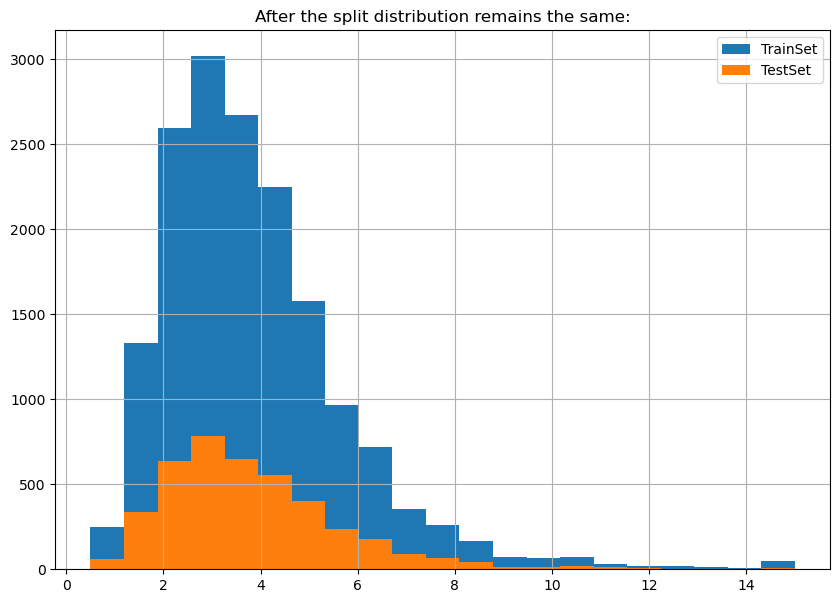

In [5]:
spliter = StratifiedShuffleSplit(n_splits=1, random_state=67, test_size=0.2)

XTrain = []
XTest = []
yTrain = []
yTest = []

for trainIndices, testIndices in spliter.split(modifiedDF, modifiedDF["incomeCategory"]):
    XTrain = rawDF.iloc[trainIndices,:].drop(columns=["median_house_value"])
    yTrain = rawDF.iloc[trainIndices, 8]
    XTest = rawDF.iloc[testIndices,:].drop(columns=["median_house_value"])
    yTest = rawDF.iloc[testIndices, 8]

plt.figure(figsize=(10, 7))
XTrain["median_income"].hist(bins=21, label="TrainSet")
XTest["median_income"].hist(bins=21, label="TestSet")
plt.title("After the split distribution remains the same:")
plt.legend(loc="best")
plt.show()

#4.  Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer: 
Two advanced regression pipelines were developed to investigate different ensemble learning strategies for house price prediction while utilizing the same preprocessing framework. The first pipeline employed the **Extreme Gradient Boosting (XGBoost) Regressor**, a gradient boosting algorithm that sequentially constructs decision trees, with each new tree learning to correct the residual errors of the previous ensemble. Through regularization, learning rate control, feature subsampling, and iterative optimization, XGBoost effectively captures complex nonlinear relationships while maintaining strong generalization performance. The second pipeline implemented a **Stacking Regressor**, an ensemble learning technique that combines multiple heterogeneous base models, namely a Random Forest Regressor and an XGBoost Regressor, whose predictions are integrated by a meta-learner based on XGBoost. By enabling **passthrough**, the meta-model utilizes both the predictions of the base learners and the original preprocessed features, allowing it to learn how to optimally combine the strengths of each model. Consequently, while the standalone XGBoost pipeline explores a single boosting-based learning strategy, the stacking pipeline investigates a higher-level ensemble approach that leverages the complementary predictive capabilities of multiple models to improve overall accuracy and robustness.


In [6]:

xgbTrainingPipeline = Pipeline([
    ("preprocessing", preProcessing),
    ("model", XGBRegressor(
    n_estimators=6_000,
    learning_rate=0.008,
    max_depth=5,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    gamma=0.1,
    random_state=67,
    objective="reg:squarederror",
    n_jobs=10))
])


stackingPipeline = Pipeline(
    [
        ("preprocessing", preProcessing),
        ("model", StackingRegressor(
            estimators=[
                ("rf",RandomForestRegressor(n_estimators=6_000,random_state=67, max_features=37, n_jobs=10)),
                ('XGB',XGBRegressor(
    n_estimators=6_000,
    learning_rate=0.008,
    max_depth=5,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    gamma=0.1,
    random_state=67,
    objective="reg:squarederror",
    n_jobs=10))
            ],
            passthrough=True,
            final_estimator=XGBRegressor(
    n_estimators=6_000,
    learning_rate=0.008,
    max_depth=5,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.11,
    reg_alpha=0.1,
    reg_lambda=1,
    gamma=0.1,
    random_state=67,
    objective="reg:squarederror",
    n_jobs=10),cv=5
        ))
    ]
)

# 5. Model Training (5 marks)

Train those 2 models



## Answer:

In [7]:

xgbTrainingPipeline.fit(XTrain, yTrain)
stackingPipeline.fit(XTrain, yTrain)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedroom', ...), ('room_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

In [8]:

xgbYTestPred = xgbTrainingPipeline.predict(XTest)
xgbAccurecy = r2_score(yTest, xgbYTestPred)
xgbLoss = root_mean_squared_error(yTest, xgbYTestPred)



stackingYTestPred = stackingPipeline.predict(XTest)
stackingForestAccurecy = r2_score(yTest, stackingYTestPred)
stackingForestLoss = root_mean_squared_error(yTest, stackingYTestPred)

print(f"""-----------XGB Performance-----------
R2 Score: {xgbAccurecy}
Loss: {xgbLoss}\n""")


print(f"""-----------StackingRegressor Performance-----------
R2 Score: {stackingForestAccurecy}
Loss: {stackingForestLoss}""")

-----------XGB Performance-----------
R2 Score: 0.8755875691209086
Loss: 40240.09594428152

-----------StackingRegressor Performance-----------
R2 Score: 0.8793127280340446
Loss: 39633.08282881222


# Answer:
The experimental results indicate that both evaluated ensemble models achieved excellent predictive performance, with the **Stacking Regressor** slightly outperforming the standalone **XGBoost Regressor**. The XGBoost model obtained an **R² score of 0.8756** and an **RMSE of 40,240.10**, demonstrating its ability to explain approximately **87.6%** of the variance in the target variable while maintaining a relatively low prediction error. The Stacking Regressor further improved these results, achieving the highest **R² score of 0.8793** and the lowest **RMSE of 39,633.08**. Although the numerical improvement is modest, it indicates that the stacking approach produced more accurate and consistent predictions. This superior performance can be attributed to the complementary strengths of its base learners. The Random Forest Regressor effectively reduces prediction variance through bagging and the aggregation of multiple decision trees, whereas the XGBoost Regressor minimizes bias by sequentially correcting prediction errors using gradient boosting. By combining the outputs of both models through an XGBoost meta-learner and incorporating the original preprocessed features via the passthrough mechanism, the Stacking Regressor was able to exploit information beyond the capabilities of either individual model. Consequently, it learned a more effective mapping between the input features and the target variable, resulting in improved generalization and lower prediction error on the California Housing dataset.


# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

In [34]:
X= rawDF.drop(columns=["median_house_value"])

unsupervisedPreprocessing = ColumnTransformer([
    ("numerical", defaultNumPipeline, X.select_dtypes(include=np.number).columns),
    ("categorical", defaultCatPipeline, X.select_dtypes(exclude=np.number).columns)
])

dimantionalityReductionPipeline = Pipeline(
    [
        ("preProcessing", preProcessing),
        ("Keeping_99%_variance", PCA(n_components=0.99, svd_solver="full")),
        ("scaleDownTo2D", TSNE(n_components=2, max_iter=6_000, random_state=67))
    ]
)

twoDRawDF = dimantionalityReductionPipeline.fit_transform(X)



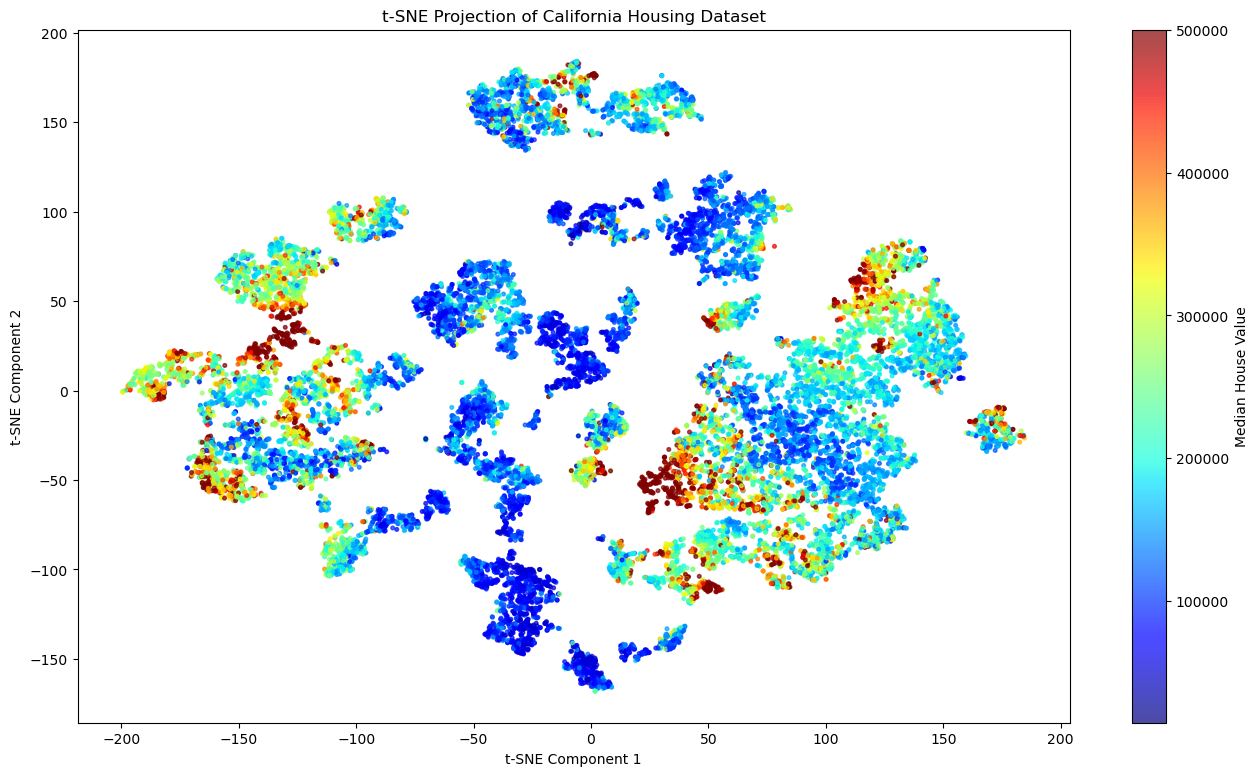

In [42]:
plt.figure(figsize=(16,9))
scatter = plt.scatter(x=twoDRawDF[:,0], y=twoDRawDF[:,1], c=rawDF["median_house_value"], 
    cmap="jet", s=7,alpha=0.7)

plt.colorbar(scatter, label="Median House Value")
plt.title("t-SNE Projection of California Housing Dataset")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

# Answer: 
The **supervised learning approach** performed better than the **unsupervised learning approach** for the California Housing dataset because the primary objective of the problem is to predict a continuous target variable, namely the median house value. The supervised models, particularly the **Stacking Regressor** and **XGBoost Regressor**, were trained using the target values and achieved excellent predictive performance, with the Stacking Regressor obtaining an **R² score of 0.8793** and an **RMSE of 39,633.08**, indicating that it successfully explained approximately **87.9%** of the variation in house prices while maintaining a low prediction error. In contrast, the unsupervised approach, which employed **PCA** followed by **t-SNE**, was designed to discover hidden structures and visualize the relationships among observations without using the target variable during training. As shown in the t-SNE visualization, several distinct clusters emerged, and regions containing similar house values exhibited comparable color distributions, suggesting that the feature set captures meaningful underlying patterns. However, noticeable color variation within many clusters indicates that the unsupervised method could not completely separate houses according to their prices. This is expected because unsupervised learning groups observations based solely on feature similarity rather than optimizing for house value prediction. Therefore, while the unsupervised approach proved valuable for exploratory data analysis and visualization of the dataset's intrinsic structure, the supervised approach was considerably more effective for the actual prediction task since it directly learned the relationship between the input features and the target variable.


#8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer:

## Hardest Topic: Gradient Descent Algorithm

The most challenging topic for me was the **Gradient Descent Algorithm**. Initially, it was difficult to understand how the algorithm iteratively updates a model's parameters to minimize the prediction error. Concepts such as the **cost function**, **learning rate**, and the optimization process required considerable practice before I fully understood how Gradient Descent converges toward the optimal solution. Implementing the algorithm and observing its behavior through practical examples greatly improved my understanding.

**Why It Is Important:**

Gradient Descent is one of the fundamental optimization algorithms in machine learning. It is widely used to train models such as **Linear Regression**, **Logistic Regression**, and **Neural Networks** by iteratively minimizing the loss function. A thorough understanding of Gradient Descent is essential because it forms the foundation of many modern machine learning and deep learning algorithms.

## Easiest Topic: K-Nearest Neighbors (KNN)

The easiest topic for me was the **K-Nearest Neighbors (KNN)** algorithm. Its working principle is intuitive and straightforward: the algorithm predicts the output for a new data point by examining the most similar data points in the training set. For classification tasks, the new instance is assigned to the class that is most common among its nearest neighbors, while for regression tasks, the prediction is based on the average value of the nearest neighbors.

**Why It Is Useful:**

KNN is easy to understand, requires minimal assumptions about the underlying data, and performs well on many classification and regression problems. It is also widely applied in recommendation systems, pattern recognition, and similarity-based applications where identifying closely related observations is important.

## Summary and Reflection

This course provided me with a comprehensive introduction to the fundamental concepts of machine learning, including data preprocessing, feature engineering, model training, hyperparameter tuning, dimensionality reduction, and model evaluation. It also gave me practical experience in implementing and comparing various machine learning algorithms such as K-Nearest Neighbors, Random Forest, XGBoost, and ensemble methods. Although understanding Gradient Descent was initially challenging, continuous practice and experimentation enabled me to grasp its underlying principles and appreciate its significance in model optimization. Overall, the course strengthened both my theoretical knowledge and practical skills, giving me greater confidence in developing, evaluating, and optimizing machine learning models for real-world applications.
